In [1]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape


(7043, 21)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

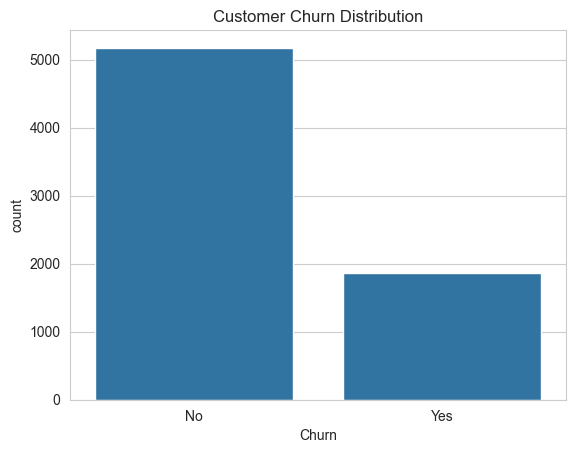

In [7]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

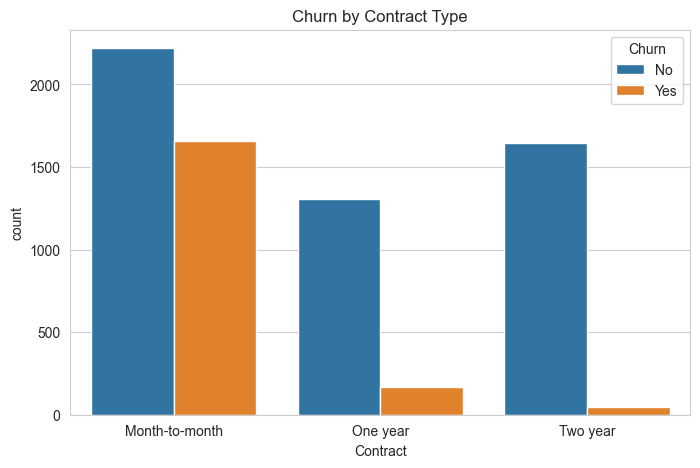

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")
plt.show()

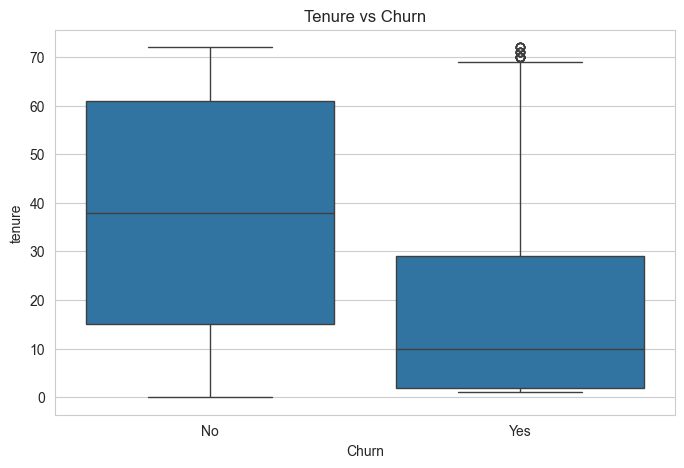

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")
plt.show()


## Insight:
Customers with month-to-month contracts show significantly higher churn rates.
## Insight:
Customers with higher monthly charges are more likely to churn.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.drop('customerID', axis=1, inplace=True)

In [16]:
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)

In [17]:
df['IsNewCustomer'] = df['tenure'].apply(lambda x: 1 if x < 12 else 0)

In [18]:
services = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = df[services].apply(
    lambda x: x.astype(str).str.contains('Yes|Fiber optic|DSL').sum(),
    axis=1
)

In [19]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,ChargesPerTenure,IsNewCustomer,TotalServices,gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,1,2,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,53.985714,0,4,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,36.050000,1,4,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,40.016304,0,4,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,50.550000,1,2,False,False,...,False,False,False,False,False,False,True,False,True,False


In [22]:
df.shape

(7032, 34)

In [23]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

In [28]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7931769722814499

ROC-AUC Score: 0.8368971015318034

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



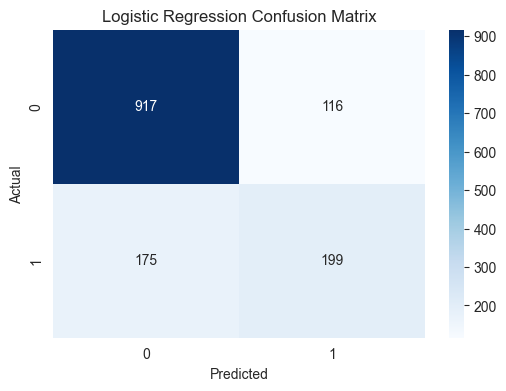

In [29]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

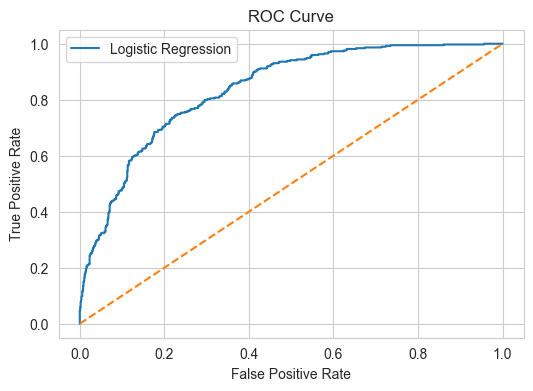

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7910447761194029

ROC-AUC Score: 0.8338479896050649

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



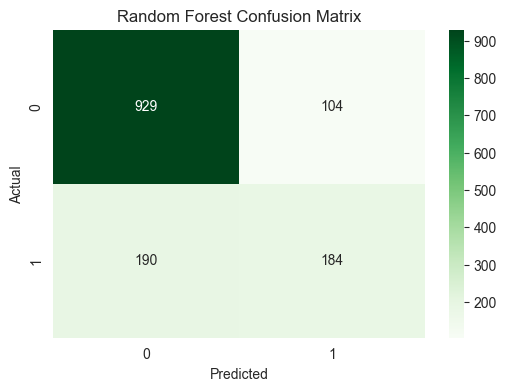

In [34]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

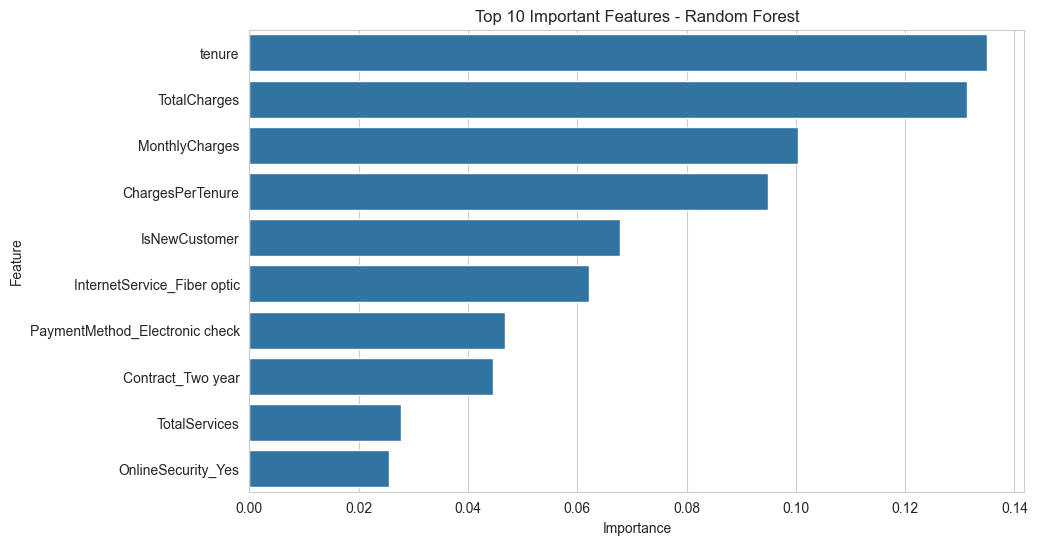

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features - Random Forest")

plt.show()

In [36]:
from xgboost import XGBClassifier

In [37]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7874911158493249

ROC-AUC Score: 0.8301297813854047

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [40]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison

,Model,ROC-AUC
0,Logistic Regression,0.836897
1,Random Forest,0.833848
2,XGBoost,0.830130


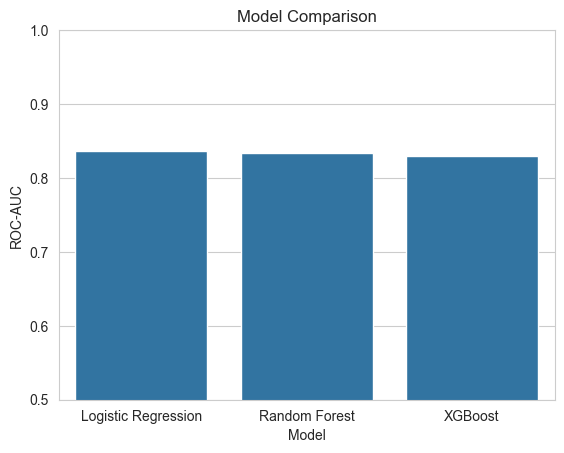

In [41]:
sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=comparison
)

plt.title("Model Comparison")

plt.ylim(0.5,1)

plt.show()

In [42]:
import shap

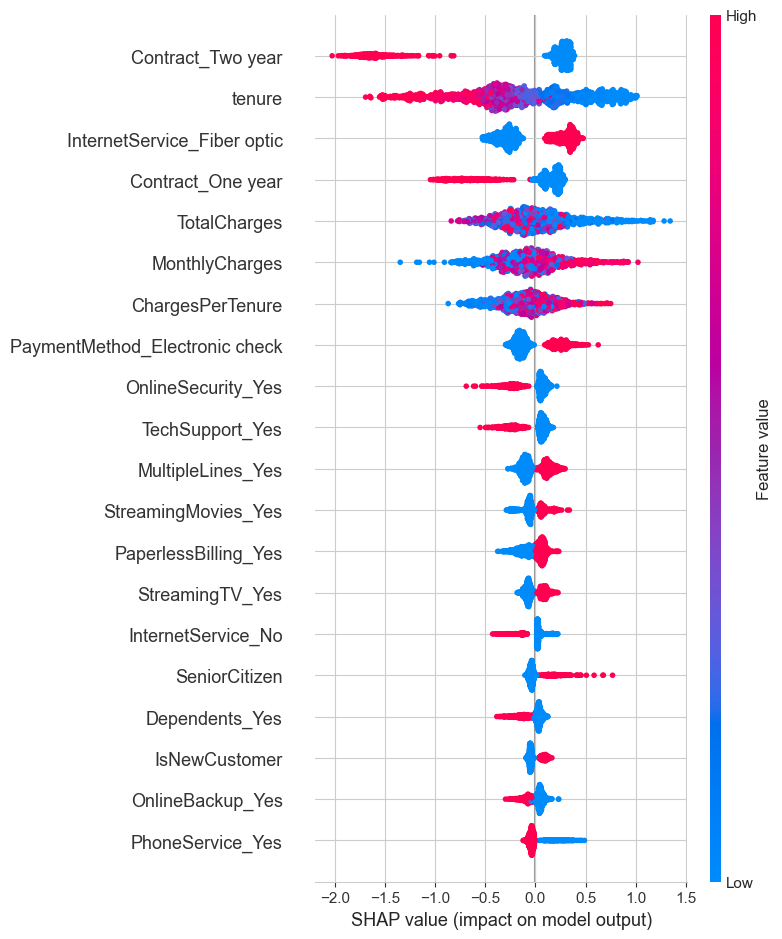

In [43]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [44]:
!pip install xgboost==1.7.6 shap==0.44.1

In [45]:
import shap

In [46]:
import numpy
print(numpy.__version__)

1.26.4


In [47]:
import numpy
print(numpy.__version__)

1.26.4


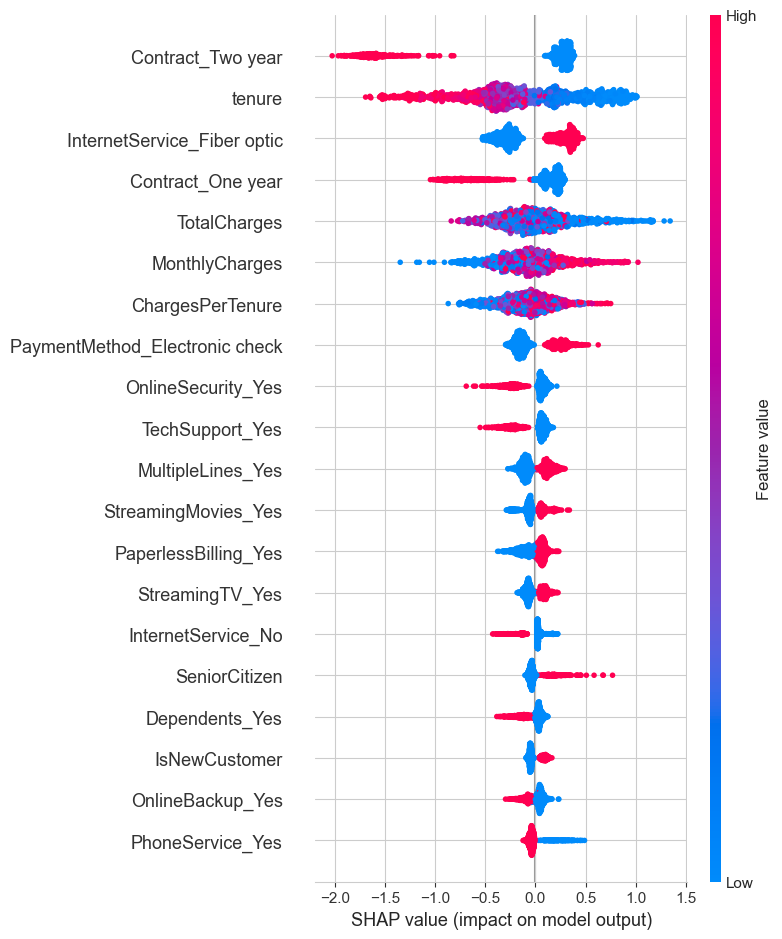

In [48]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [49]:
print(type(xgb_model))


<class 'xgboost.sklearn.XGBClassifier'>


In [50]:
import shap

print("SHAP imported")

SHAP imported


In [51]:
explainer = shap.TreeExplainer(xgb_model)

print("Explainer created")

Explainer created


In [52]:
import joblib

joblib.dump(xgb_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [53]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

# Model Performance

The XGBoost model achieved the best performance among all tested models.
# Explainable AI Insights

SHAP analysis revealed that contract type, tenure, and monthly charges were the strongest drivers of customer churn.

In [54]:
import joblib

joblib.dump(xgb_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [55]:
import joblib

model = joblib.load("../models/churn_model.pkl")

In [56]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'IsNewCustomer', 'TotalServices', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [57]:
import joblib

joblib.dump(xgb_model, "models/churn_model.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")

print("Saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_model.pkl'

In [58]:
import os

os.makedirs("models", exist_ok=True)

print("models folder created")

models folder created


In [59]:
import joblib

joblib.dump(xgb_model, "models/churn_model.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")

print("Saved successfully!")

Saved successfully!


In [60]:
import os

print(os.listdir("models"))

['churn_model.pkl', 'feature_names.pkl']


In [61]:
import os

print(os.getcwd())

c:\Users\Gopika\OneDrive\Documents\Desktop\Telecom-Churn-Prediction\notebooks


In [62]:
import os
print(os.listdir("models"))

['churn_model.pkl', 'feature_names.pkl']


In [63]:
model = joblib.load("../models/churn_model.pkl")
feature_names = joblib.load("../models/feature_names.pkl")